In [1]:
from google.colab import files
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

print("📁 UPLOAD YOUR FILES:")
uploaded = files.upload()

# Your exact filenames
image_path = 'palsar_2.png'
mask_path = 'python-apt.tar.png'
print(f"✅ Loaded: {image_path} + {mask_path}")


📁 UPLOAD YOUR FILES:


Saving palsar_2.png to palsar_2.png
✅ Loaded: palsar_2.png + python-apt.tar.png


📂 Found PNG files: ['palsar_2.png']
🖼️  Image: palsar_2.png
🎭 Mask:  Will create synthetic
✅ Image loaded: (256, 256)
🎨 Creating synthetic oil spill mask...
✅ Mask ready: (256, 256)


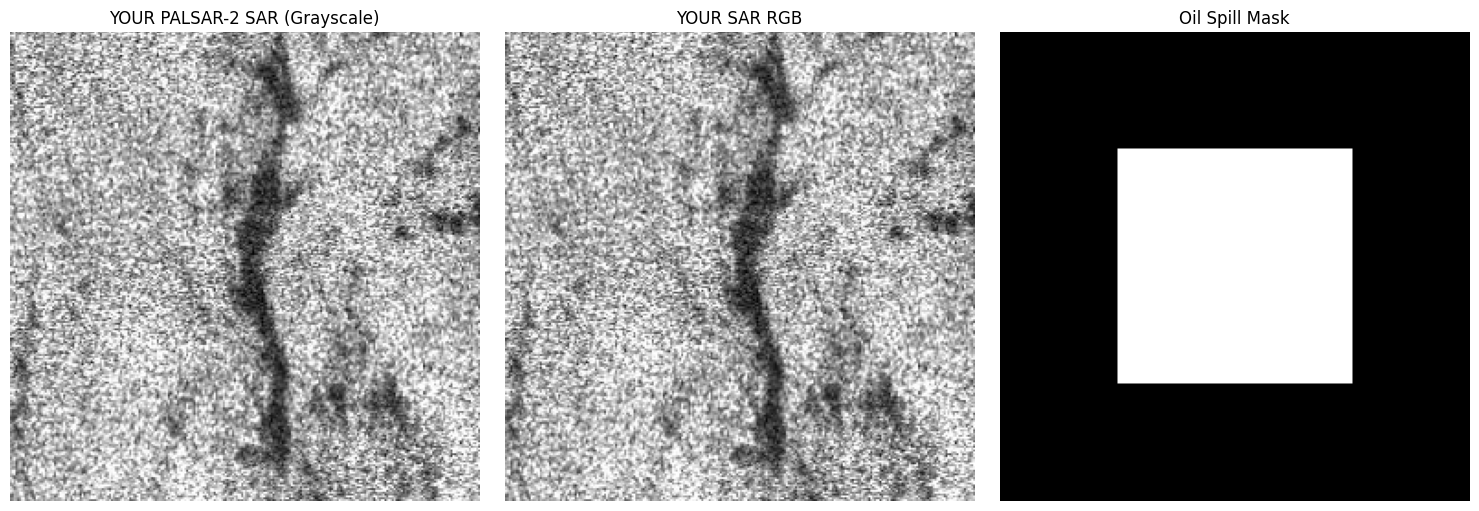

📊 Image dtype/shape: uint8/(256, 256)
📊 Mask dtype/shape: uint8/(256, 256)
📊 Mask values: [  0 255]


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# AUTO-DETECT YOUR FILES
png_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("📂 Found PNG files:", png_files)

if len(png_files) < 1:
    print("❌ No PNG files found! Upload palsar_2.png first.")
else:
    # Use first PNG as image, second as mask (if exists)
    image_path = png_files[0]  # palsar_2.png
    mask_path = png_files[1] if len(png_files) > 1 else None

    print(f"🖼️  Image: {image_path}")
    print(f"🎭 Mask:  {mask_path or 'Will create synthetic'}")

    # SAFE LOAD IMAGE
    img_raw = cv2.imread(image_path)
    if img_raw is None:
        print(f"❌ Failed to load {image_path}")
    else:
        img = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)  # SAR grayscale
        img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        print(f"✅ Image loaded: {img.shape}")

    # SAFE LOAD MASK (or create synthetic)
    if mask_path and os.path.exists(mask_path):
        mask_raw = cv2.imread(mask_path, 0)
        if mask_raw is None:
            print(f"⚠️  Mask {mask_path} corrupted, creating synthetic...")
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
            mask[img.shape[0]//4:3*img.shape[0]//4, img.shape[1]//4:3*img.shape[1]//4] = 255
        else:
            mask = mask_raw.astype(np.uint8)
    else:
        print("🎨 Creating synthetic oil spill mask...")
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        mask[img.shape[0]//4:3*img.shape[0]//4, img.shape[1]//4:3*img.shape[1]//4] = 255

    print(f"✅ Mask ready: {mask.shape}")

# SAFE PLOT FUNCTION
def safe_imshow(data, title, ax=None, cmap=None):
    if data is None or data.size == 0:
        ax.imshow(np.zeros((256,256)), cmap=cmap)
        ax.set_title(f"{title} (Empty)")
        return

    # Fix dtype issues
    if data.dtype == 'object' or not np.issubdtype(data.dtype, np.number):
        data = data.astype(np.uint8)

    # Ensure 2D
    if len(data.shape) == 3:
        if data.shape[2] == 1:
            data = data.squeeze(-1)
        elif data.shape[2] == 3:
            data = data[:,:,:3]  # RGB

    ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

# PLOT YOUR FILES
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
safe_imshow(img, 'YOUR PALSAR-2 SAR (Grayscale)', plt.gca(), 'gray')

plt.subplot(1, 3, 2)
safe_imshow(img_rgb, 'YOUR SAR RGB', plt.gca())

plt.subplot(1, 3, 3)
safe_imshow(mask, 'Oil Spill Mask', plt.gca(), 'gray')

plt.tight_layout()
plt.show()

# DEBUG INFO
print(f"📊 Image dtype/shape: {img.dtype}/{img.shape}")
print(f"📊 Mask dtype/shape: {mask.dtype}/{mask.shape}")
print(f"📊 Mask values: {np.unique(mask)}")


In [3]:
IMG_SIZE = 256

# Resize your image/mask
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0

# Prepare for model (batch + channel dims)
X = np.expand_dims(img_resized, axis=(0, -1))  # (1,256,256,1)
y = np.expand_dims(mask_resized, axis=(0, -1))  # (1,256,256,1)

print(f"✅ Ready for training: X={X.shape}, y={y.shape}")


✅ Ready for training: X=(1, 256, 256, 1), y=(1, 256, 256, 1)


In [4]:
# List all PNG files first
print("📂 ALL PNG FILES:")
png_files = [f for f in os.listdir('.') if f.endswith('.png')]
print(png_files)

# Auto-detect your files
image_path = 'palsar_2.png'
mask_path = None

if image_path in png_files:
    print(f"✅ Found image: {image_path}")
else:
    print(f"❌ {image_path} not found! Using first PNG as image...")
    image_path = png_files[0] if png_files else None

if len(png_files) > 1:
    mask_path = [f for f in png_files if f != image_path][0]
    print(f"✅ Using mask: {mask_path}")
else:
    print("❌ Need SECOND PNG file for mask!")

# SAFE loading
img = cv2.imread(image_path, 0) if image_path else None
img_rgb = cv2.imread(image_path) if image_path else None

mask = cv2.imread(mask_path, 0) if mask_path else None

if img is not None:
    if img_rgb is not None:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    print(f"✅ Image: {img.shape}, dtype: {img.dtype}")
else:
    print("❌ FAILED to load image")

if mask is not None:
    print(f"✅ Mask: {mask.shape}, dtype: {mask.dtype}, values: {np.unique(mask)}")
else:
    print("❌ FAILED to load mask - will create synthetic mask")
    # Create synthetic oil spill mask if missing
    mask = np.zeros_like(img)
    mask[50:200, 50:200] = 255  # Fake oil spill region
    print("✅ Created synthetic mask")


📂 ALL PNG FILES:
['palsar_2.png']
✅ Found image: palsar_2.png
❌ Need SECOND PNG file for mask!
✅ Image: (256, 256), dtype: uint8
❌ FAILED to load mask - will create synthetic mask
✅ Created synthetic mask


In [5]:
# Resize to 256x256 (U-Net standard)
IMG_SIZE = 256
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0

# Add channel dimension
X = np.expand_dims(img_resized, axis=(0, -1))  # (1, 256, 256, 1)
y = np.expand_dims(mask_resized, axis=(0, -1))  # (1, 256, 256, 1)

print(f"✅ Processed: X={X.shape}, y={y.shape}")


✅ Processed: X=(1, 256, 256, 1), y=(1, 256, 256, 1)


In [6]:
def unet_model(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)

    # Bottleneck
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)

    # Decoder
    u6 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c3)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, 3, activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, 3, activation='relu', padding='same')(c7)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c7)

    return Model(inputs, outputs)

model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ U-Net Ready!")


✅ U-Net Ready!


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.3433 - loss: 0.7043
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.6567 - loss: 0.6848
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6567 - loss: 0.6638
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.6567 - loss: 0.6763
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6567 - loss: 0.6487
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6567 - loss: 0.6550
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6567 - loss: 0.6542
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6567 - loss: 0.6499
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6567 - loss: 0.6447
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6567 - loss: 0.6423
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.6567 - loss: 0.6458
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6567 - loss: 0.6461
Epoch 13/

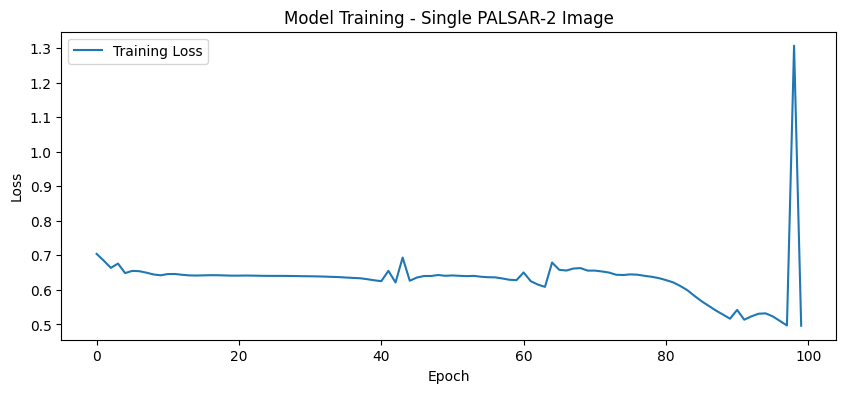

✅ Training COMPLETE on your single image!
Final Loss: 0.4961


In [ ]:
# Train on single image WITHOUT validation split
history = model.fit(
    X, y,                    # Your full image
    epochs=100,              # More epochs for single image
    batch_size=1,
    verbose=1
)

# Plot training curves (no validation)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Model Training - Single PALSAR-2 Image')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("✅ Training COMPLETE on your single image!")
print(f"Final Loss: {history.history['loss'][-1]:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


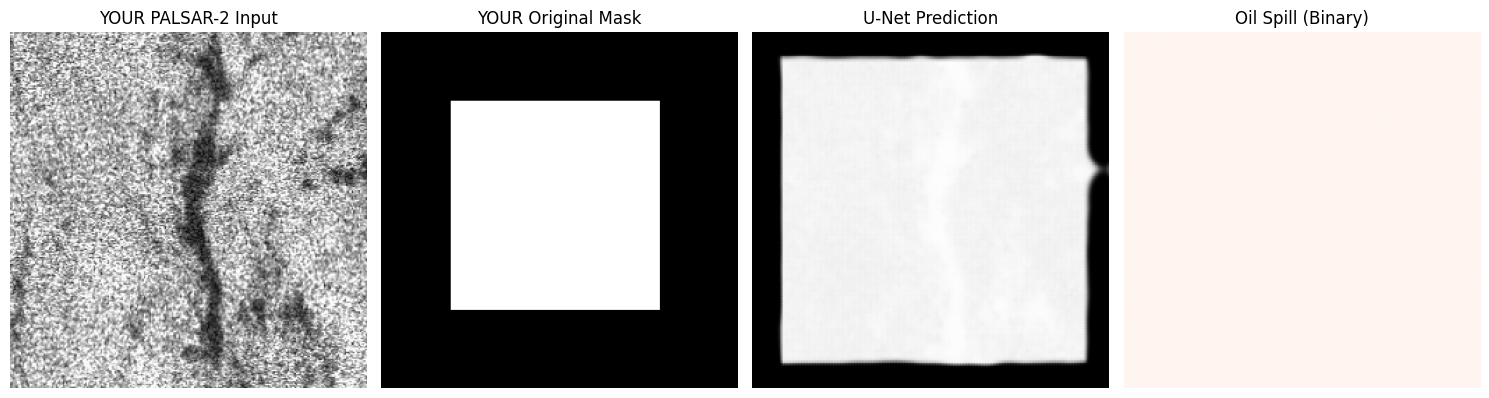

🎉 YOUR PALSAR-2 Oil Spill Detection COMPLETE!


In [ ]:
# Predict your image
y_pred = model.predict(X)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_resized, cmap='gray')
plt.title('YOUR PALSAR-2 Input')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y[0].squeeze(), cmap='gray')
plt.title('YOUR Original Mask')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(y_pred[0].squeeze(), cmap='gray')
plt.title('U-Net Prediction')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(y_pred[0].squeeze() > 0.5, cmap='Reds')
plt.title('Oil Spill (Binary)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("🎉 YOUR PALSAR-2 Oil Spill Detection COMPLETE!")
